# Transition-specific ITIs with `conditional_ITI`

This tutorial shows how to assign different ITI distributions to different event transitions. The goal is to model tasks in which the gap before an event depends on what just happened, rather than using one global ITI rule everywhere.

By the end, you will know how to:

1. define a `conditional_ITI` dictionary,
2. understand how `default` and `(previous_event, current_event)` keys interact,
3. inspect the resulting event-specific timing in an optimized design.


In [1]:
import os

os.environ["OMP_NUM_THREADS"] = "1"
os.environ["OPENBLAS_NUM_THREADS"] = "1"
os.environ["MKL_NUM_THREADS"] = "1"

import matplotlib.pyplot as plt
import numpy as np
import neurodesign

plt.rcParams["figure.figsize"] = (10, 4)
plt.rcParams["figure.dpi"] = 110


## 1. When to use `conditional_ITI`

A single global ITI is enough when every transition in the task follows the same timing rule. `conditional_ITI` becomes useful when the gap depends on the transition itself. For example, cue-to-target may be short, while feedback-to-next-trial may be longer.

`neurodesign-plus` encodes that logic with a dictionary:

- keys of the form `(previous_event, current_event)` define transition-specific timing,
- `"default"` is used for the first event and for any transition not explicitly listed,
- the experiment container still requires global ITI summary values such as `ITImean` and `ITImax`.

For this tutorial, we keep the event order fixed so the only changing element is the ITI sampling.


In [2]:
fixed_order = [0, 1, 2, 3] * 5

conditional_iti = {
    (0, 1): {"model": "uniform", "mean": 2.5, "min": 1, "max": 4},
    (2, 3): {"model": "exponential", "mean": 2.5, "min": 1, "max": 4},
    "default": {"model": "fixed", "mean": 1.5},
}

print("First 8 event transitions in the fixed order:")
print(list(zip([None] + fixed_order[:-1], fixed_order))[:8])


First 8 event transitions in the fixed order:
[(None, 0), (0, 1), (1, 2), (2, 3), (3, 0), (0, 1), (1, 2), (2, 3)]


## 2. Build the experiment

The experiment below uses `conditional_ITI` to specify the gap before each event. Notice that `ITImean` and `ITImax` are still present: they define the stable container used for the experiment, while the dictionary determines the concrete ITIs sampled for each design.

**Key parameters explained:**

- `conditional_ITI` controls the actual event-level ITI draws.
- `ITImean` gives the experiment an expected ITI for computing its shared timing container.
- `ITImax` should be large enough to cover the longest ITI that any transition can generate.
- `order=fixed_order` is used here only to isolate the ITI feature in a readable example.


In [3]:
exp = neurodesign.Experiment(
    TR=2,
    n_trials=len(fixed_order),
    P=[0.25, 0.25, 0.25, 0.25],
    C=[[1, 0, -1, 0], [1, 0, 0, -1], [0, 1, -1, 0], [0, 1, 0, -1]],
    n_stimuli=4,
    rho=0.3,
    stim_duration=1,
    t_pre=1,
    t_post=0.5,
    ITImodel="exponential",
    ITImin=1,
    ITImax=4,
    ITImean=2,
    conditional_ITI=conditional_iti,
    order=fixed_order,
)

population = neurodesign.Optimisation(
    experiment=exp,
    R=[1, 0, 0],
    weights=[0, 0.5, 0.25, 0.25],
    preruncycles=10,
    cycles=25,
    folder="./",
    seed=100,
)

population.optimise()


c:\Users\vguigon\Desktop\Research_directory\Lab_SLD\neurodesign-plus\neurodesign\classes.py:679: UserWarning: the resolution is adjusted to be a multiple of the TR. New resolution: 0.1
  warnings.warn(
c:\Users\vguigon\Desktop\Research_directory\Lab_SLD\neurodesign-plus\neurodesign\classes.py:846: RuntimeWarning: divide by zero encountered in log
  res = (h - 1) * np.log(s) + h * np.log(l) - l * s - np.log(gamma(h))


Output()

Output()

First 10 transition-specific ITIs:
(None, 0): 1.5
(0, 1): 3.3
(1, 2): 1.5
(2, 3): 1.3
(3, 0): 1.5
(0, 1): 1.0
(1, 2): 1.5
(2, 3): 2.2
(3, 0): 1.5
(0, 1): 1.8
Fd (detection efficiency): 1.0027
Fe (estimation efficiency): 0.0000
Fc (confounding score): 0.2165
Ff (frequency-balance score): 1.0000


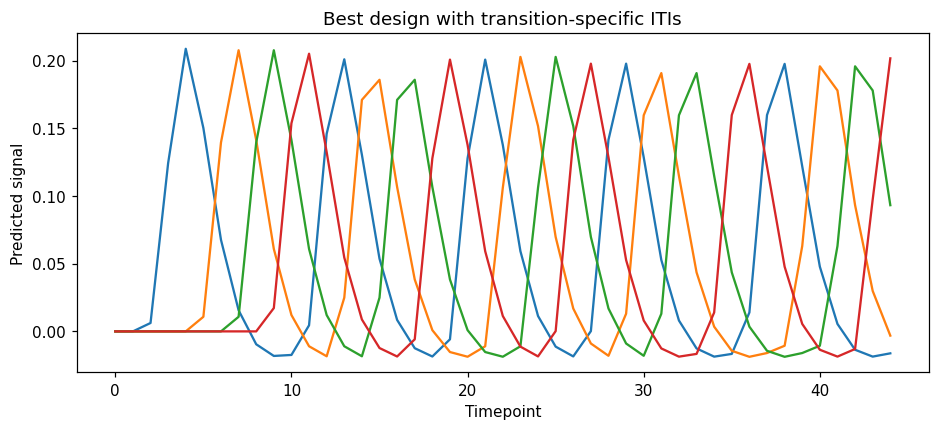

In [4]:
best_design = population.bestdesign
best_design.designmatrix()

pairs = list(zip([None] + list(best_design.order[:-1]), list(best_design.order)))
print("First 10 transition-specific ITIs:")
for pair, iti in list(zip(pairs, np.round(best_design.ITI, 2)))[:10]:
    print(f"{pair}: {iti}")

print(f"Fd (detection efficiency): {best_design.Fd:.4f}")
print(f"Fe (estimation efficiency): {best_design.Fe:.4f}")
print(f"Fc (confounding score): {best_design.Fc:.4f}")
print(f"Ff (frequency-balance score): {best_design.Ff:.4f}")

fig, ax = plt.subplots()
ax.plot(best_design.Xconv)
ax.set_title("Best design with transition-specific ITIs")
ax.set_xlabel("Timepoint")
ax.set_ylabel("Predicted signal")
plt.show()


## 3. Interpreting the plot

The order is fixed, so differences in spacing come from the ITIs rather than from order changes. The printed `(previous, current)` pairs let you verify that:

- `(0, 1)` transitions use their own distribution,
- `(2, 3)` transitions use a different one,
- all remaining transitions fall back to `default`.

If the convolved design matrix shows flat space at the end, that does not necessarily mean anything is wrong. The `Experiment` object builds a stable timing container from expected values (`ITImean`, `trial_max`, `t_pre`, `t_post`), and a particular sampled design can finish earlier than that container.


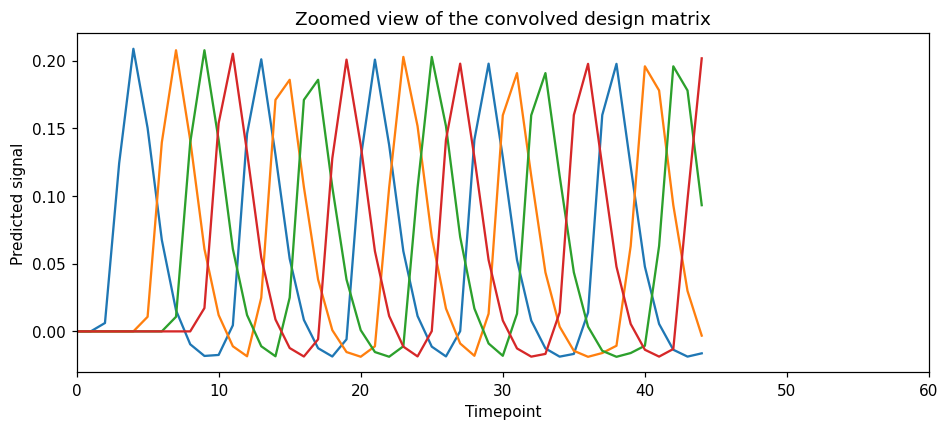

In [5]:
plt.figure(figsize=(10, 4))
plt.plot(best_design.Xconv)
plt.xlim(0, 60)
plt.title("Zoomed view of the convolved design matrix")
plt.xlabel("Timepoint")
plt.ylabel("Predicted signal")
plt.show()


## 4. Takeaway

Use `conditional_ITI` when the timing before an event depends on the transition that produced it. The pattern to remember is:

- specify transition rules with `(previous_event, current_event)`,
- include a `default` rule for everything else,
- keep `ITImean` and `ITImax` consistent with the range of ITIs the design may generate.
